# Load in the libs
### This notebook can test either the direct Linux-to-Windows SLM client or the Linux SHM bridge. The bridge path is the default: Linux owns the Windows connection, watches a pymilk SHM, and forwards every SHM update to the Windows SLM server.


tmux attach -t pwi_servers

In [1]:
# Python Libs
import multiprocessing as mp
import time

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')


# import Jazlabs.hardware.SLM.MeadowlarkBlinkPlus.MeadowlarkBlinkPlusObject as slmlib
# import Jazlabs.hardware.SLM.MeadowlarkBlinkOverDrivePlus.MeadowlarkBlinkOneDrivePlusObject as slmlib
import JazLabs.utils.GenerateSimplePhaseMasks as slm_masks
import JazLabs.hardware.SLM.PhaseMaskClass as PhaseMaskClass
import JazLabs.hardware.SLM.SLMStack.SLM_Client as SLM_Clientlib

import JazLabs.procedures.SLM.SLM_PhaseCalibration as SLM_PhaseCalibration

import JazLabs.hardware.Cameras.Camera_Client as CamClientlib
import JazLabs.utils.camera_utils as cam_utils


In [3]:
# %load_ext autoreload
# %aimport Jazlabs.hardware.SLM.SLMStackMilk.SLM_ServerLinux 
# %aimport Jazlabs.hardware.SLM.SLMStackMilk.SLM_ClientLinux 
# %aimport Jazlabs.hardware.SLM.graveyard.SLM_DirectClient
# %aimport Jazlabs.hardware.SLM.SLMStackMilk.SLM_ViewerLinux
# %aimport Jazlabs.hardware.SLM.PhaseMaskClass
# %aimport Jazlabs.hardware.Cameras.Camera_Server
# %aimport Jazlabs.hardware.Cameras.Camera_Client
# %aimport Jazlabs.hardware.Cameras.Camera_Viewer
# %aimport Jazlabs.hardware.Cameras.Camera_Widget
# %autoreload 1


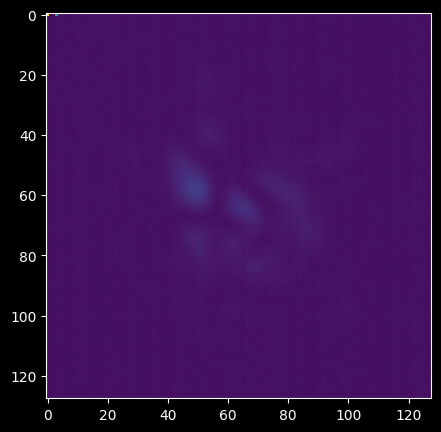

In [4]:
try:
    cam_slm.close()
except NameError:
    pass

cam_slm = CamClientlib.CameraClient(
    host="127.0.0.1",
    command_port=50733,
    frame_pub_port=50734,
    timeout_ms=5000,
    client_id="camera_notebook",
)

properties = cam_slm.GetProperties()
plt.imshow(cam_slm.GetFrame())


In [5]:
try:
    slmobj_client.close()
except NameError:
    pass
slmobj_client = SLM_Clientlib.SLMObject(
    host='127.0.0.1',
    command_port=5555,
    display_pub_port=5556,
    timeout_ms=5000,
    attach_viewer_shared_memory=False,
)

In [6]:
phasemaskobj = PhaseMaskClass.PhaseMaskObject(
    SLMObject=slmobj_client,
    ActiveRGBChannels=["Red"],
    pixel_size=17e-6,
    wavelength=1550e-9,
)



        Zern Coefs:
        0:  piston    ( 0,  0 )
        1:  Tiltx     (1,  -1 )
        2:  Tilty     ( 1,  1 )
        3:  Astigx    (2,  -2 )
        4:  Defocus   ( 2,  0 )
        5:  Astigy    ( 2,  2 )
        6:  Trefilx   (3,  -3 )
        7:  Comax     (3,  -1 )
        8:  Comay     ( 1,  3 )
        9:  Trefoily  ( 3,  3 )
        12:  Spherical ( 4,  0 )
        
1024
1024
[  1   1 256 256]


In [9]:

# trun the Vpol mask off
phasemaskobj.polProps["Red"]['V'].polEnabled=False
# move Hpol mask to center
phasemaskobj.AllMaskProperties["Red"]["H"][0].center[1] = 455
phasemaskobj.AllMaskProperties["Red"]["H"][0].center[0] = 700
phasemaskobj.setmask(channel="Red",imode=0)

In [7]:
MaskCMPLX=slm_masks.binary_stripe_phase(Nx=slmobj_client.monitor_width, Ny=slmobj_client.monitor_height, stripe_width=25, phase_value=0, orientation="vertical")
MaskInt=phasemaskobj.convert_phase_to_uint8( arr=(MaskCMPLX[0,0,:,:]))
check=bool(slmobj_client.WriteImageToSLM(MaskInt,wait=True))

In [9]:
phasemaskobj.Clear_Display()

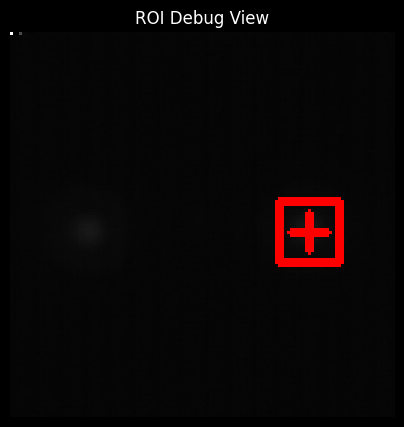

In [8]:
## Middle spot is at centre=[128,128],x_half_width=17,y_half_width=17
## Left spot is at centre=[128,63],x_half_width=17,y_half_width=17
## Right spot is at centre=[128,192],x_half_width=17,y_half_width=17

# cam_slm.FireSoftwareTrigger()
frame=cam_slm.GetFrame() 
# pwrAfterReflat=cam_utils.get_relative_power(frame=frame_Reblankslm,centre=[148,159],x_half_width=17,y_half_width=17)
cam_utils.show_aperture(frame=frame,centre=[66,99],x_half_width=10,y_half_width=10)

In [46]:
cam_slm.SetFrameWatchdog(timeout_s=1.0, action="reset")

{'timeout_s': 1.0, 'action': 'reset'}

In [11]:
phasemaskobj.LoadMaskProperties(filenamePrefix="SLM_CenterAlignment.npy",PolSelector="H")


0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247 248 249 250 251 252 253 254 255 

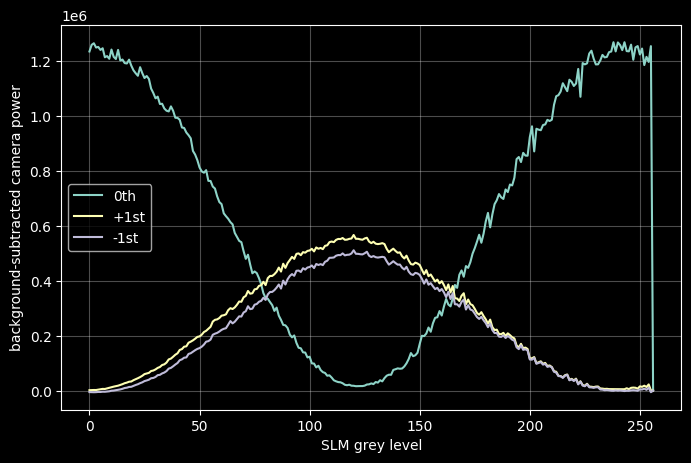

In [14]:
phase_cal_0th, phase_cal_plus1st, phase_cal_minus1st = (
    SLM_PhaseCalibration.PhaseCalibration_BinaryDiffraction_Cam_0thAnd1stOrder(
        slm=phasemaskobj,
        Cam=cam_slm,
        channel="Red",
        Direction="y",
        imask=0,
        pol="H",
        backgroundLevel=0,
        strip_width=25,
        camframeAvg=1,
        ixCamCenter0th=66,
        iyCamCenter0th=63,
        ixCamCenter_plus1st=66,
        iyCamCenter_plus1st=99,
        ixCamCenter_minus1st=66,
        iyCamCenter_minus1st=26,
        x_half_width=10,
        y_half_width=10,
    )
)

levels = np.arange(phase_cal_0th.size)
plt.figure(figsize=(8, 5))
plt.plot(levels, phase_cal_0th, label="0th")
plt.plot(levels, phase_cal_plus1st, label="+1st")
plt.plot(levels, phase_cal_minus1st, label="-1st")
plt.xlabel("SLM grey level")
plt.ylabel("background-subtracted camera power")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



phi_end = 2.6269282891233687


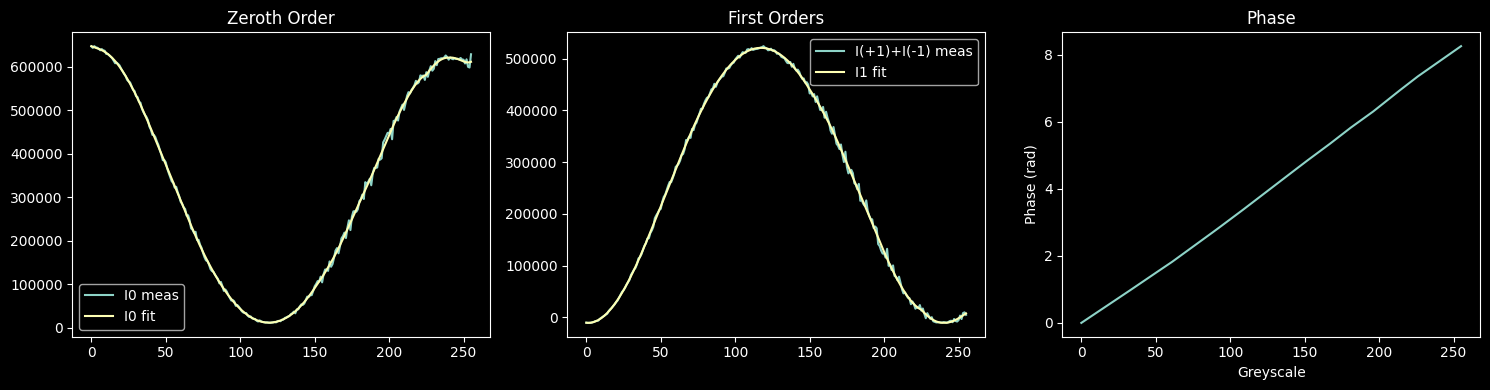

In [35]:
import JazLabs.procedures.SLM.SLMPhaseCalibrationFunctions as PhaseCal_ana

plt.rcParams['figure.figsize'] = [2,2]

# g = np.arange(256)
g = np.arange(phase_cal_0th.size-1)

I0=phase_cal_0th[:-1]
Iplus1=phase_cal_plus1st[:-1]
Iminus1=phase_cal_minus1st[:-1]
# res = PhaseCal_ana.fit_slm_phase_I0_Ipm1(g, I0, Iplus1, Iminus1,n_knots=18, poly_deg=8,
                                #   phi_max_guess=7*np.pi, lam_curv=0.2,robust=False)
res = PhaseCal_ana.fit_slm_phase_I0_Ipm1(g, I0, Iplus1, Iminus1,n_knots=18, poly_deg=10,
                                  phi_max_guess=3*np.pi, lam_curv=0.2,robust=False)
phi = res["phi"]          # fitted phase vs greyscale
print("phi_end =", res["phi_end"]/np.pi)
fig, ax = plt.subplots(1, 3, figsize=(15, 4), sharex=False)

# ---- Plot 1 ----
ax[0].plot(res["g"], I0, label="I0 meas")
ax[0].plot(res["g"], res["I0_fit"], label="I0 fit")
ax[0].set_title("Zeroth Order")
ax[0].legend()

# ---- Plot 2 ----
ax[1].plot(res["g"], res["I1_sum"], label="I(+1)+I(-1) meas")
ax[1].plot(res["g"], res["I1_fit"], label="I1 fit")
ax[1].set_title("First Orders")
ax[1].legend()

# ---- Plot 3 ----
ax[2].plot(res["g"], res["phi"])
ax[2].set_title("Phase")
ax[2].set_xlabel("Greyscale")
ax[2].set_ylabel("Phase (rad)")

plt.tight_layout()
plt.show()

In [147]:
np.savez('../calibrations/SLM/CustomLutFiles/PowerPhaseCal_75C_5.npz', PowerValues_0th=phase_cal_0th, PowerValues_plus1st=phase_cal_plus1st,PowerValues_minus1st=phase_cal_minus1st)


In [148]:
mplcIdx=0
wavelen=1550-9
flipCamImag=False;
flipFields=True;
TransposeFields=False;
flipMetricMatrices=False;#This should be set to true for the XGates results 
# foldername='..'+slash+'..'+slash+'Main';
foldername='Data';



# Linear lut
Filename="1024x1024_linearVoltage.lut"
Filename="NewLutFile_3.lut"
# Filename="Lut_mplc0_linearCal.lut"




# power Data
# /home/pllab-vis/Documents/DansWork/PWI-inst/calibrations/SLM/CustomLutFiles
Filename_powervalues="../calibrations/SLM/CustomLutFiles/PowerPhaseCal_75C_5.npz"
data = np.load(Filename_powervalues)
PowerValues_0th = data['PowerValues_0th']
PowerValues_plus1st = data['PowerValues_plus1st']
PowerValues_minus1st = data['PowerValues_minus1st']

# filePathMode=foldername+slash+"phaseCal_1550MaskNum0.mat"

NewLutfilename="NewLutFile"

# Folder="C:"+slash+"Program Files"+slash+"Meadowlark Optics"+slash+"Blink 1920 HDMI"+slash+"LUT Files"+slash
# Folder="C:"+slash+"Program Files"+slash+"Meadowlark Optics"+slash+"Blink OverDrive Plus"+slash+"LUT Files"+slash

Folder="../calibrations/SLM/CustomLutFiles/"
LutFilename=Folder+Filename

generateLUT=True



phi_end = 2.1050271285587665


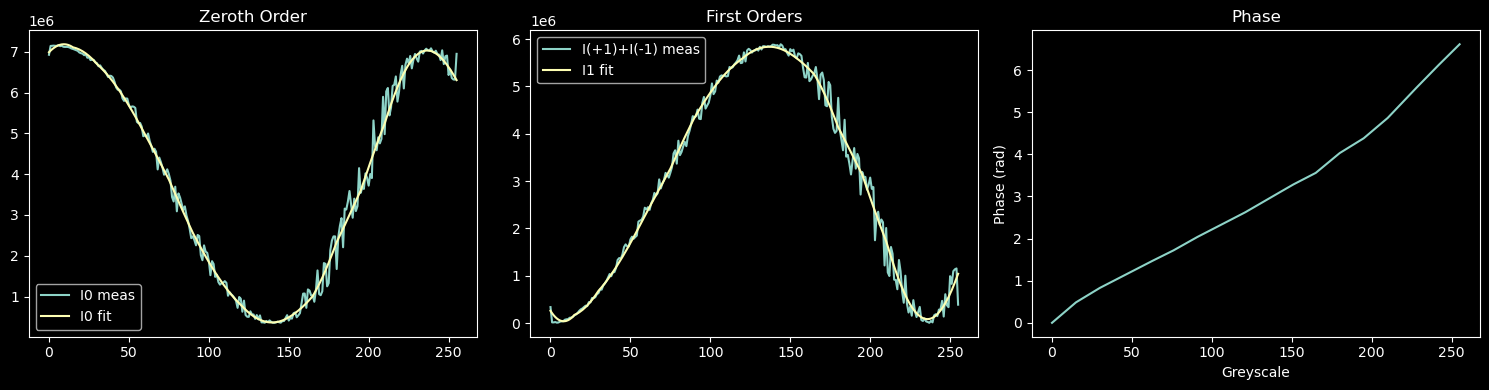

In [149]:
plt.rcParams['figure.figsize'] = [2,2]

g = np.arange(256)

I0=PowerValues_0th[:-1]
Iplus1=PowerValues_plus1st[:-1]
Iminus1=PowerValues_minus1st[:-1]
# res = PhaseCal.fit_slm_phase_I0_Ipm1(g, I0, Iplus1, Iminus1,n_knots=18, poly_deg=8,
                                #   phi_max_guess=6*np.pi, lam_curv=0.2,robust=False)
res = PhaseCal_ana.fit_slm_phase_I0_Ipm1(g, I0, Iplus1, Iminus1,n_knots=18, poly_deg=2,
                                  phi_max_guess=3*np.pi, lam_curv=0.2,robust=False)
phi = res["phi"]          # fitted phase vs greyscale
print("phi_end =", res["phi_end"]/np.pi)
fig, ax = plt.subplots(1, 3, figsize=(15, 4), sharex=False)

# ---- Plot 1 ----
ax[0].plot(res["g"], I0, label="I0 meas")
ax[0].plot(res["g"], res["I0_fit"], label="I0 fit")
ax[0].set_title("Zeroth Order")
ax[0].legend()

# ---- Plot 2 ----
ax[1].plot(res["g"], res["I1_sum"], label="I(+1)+I(-1) meas")
ax[1].plot(res["g"], res["I1_fit"], label="I1 fit")
ax[1].set_title("First Orders")
ax[1].legend()

# ---- Plot 3 ----
ax[2].plot(res["g"], res["phi"])
ax[2].set_title("Phase")
ax[2].set_xlabel("Greyscale")
ax[2].set_ylabel("Phase (rad)")

plt.tight_layout()
plt.show()


phaseCount=np.size(phi)
OverlapSigRef=np.exp(1j*phi)
OverlapRefRef=phi
OverlapSigSig=phi

Hi 256
Total phase stroke(Max Phase - Min Phase) = 2.105 pi (6.614 rad)

Max Phase Shift Allowed ( (Max Phase - Min Phase)-2pi) = (0.330 rad)

Number of points after Max= 1
703


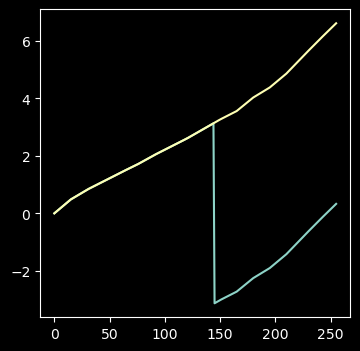

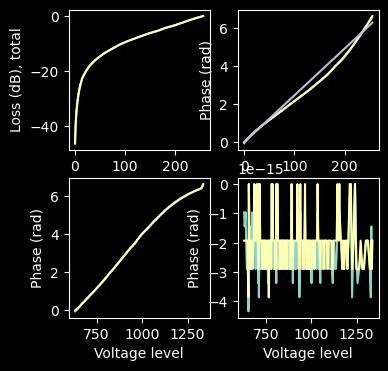

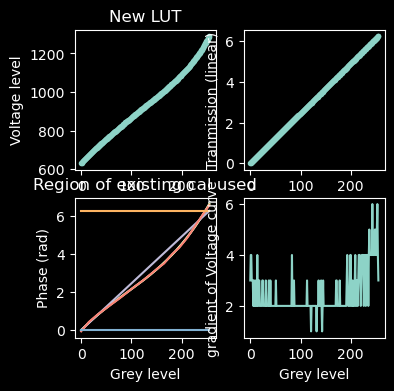

minGradVolt should be great then or equal to one. minGradVolt= 1.0 AvgGradVolt= 2.4609375
minGradPhase should not be less or equal to zero then zero. minGradPhase= 0.01577778863959356 AvgGradPhase= 0.02452575103263597 StdGradPhase= 0.002193452960072182


In [151]:
plt.rcParams['figure.figsize'] = [4,4]
phaseCalOffset =0.00
phaseStroke = 2.0*np.pi;
ipolRef=1
ipolSig=0
PhaseCalResults=PhaseCal_ana.CalculatePhaseAndVoltageLevels(generateLUT,LutFilename,NewLutfilename,phaseCount,phaseStroke,phaseCalOffset,OverlapSigRef,OverlapRefRef,OverlapSigSig)


# When you setup ssh key this should work to move the lut file over to the windows machine but for the time being just use

scp NewLutFile.lut pllab-vis@10.196.0.67:"C:\SLM_LUTFiles\SLM7635_at650_75c_4.lut"

In [ ]:
# import subprocess
# from pathlib import Path

# src = Path(NewLutfilename + ".LUT")
# dst_name = "SLM_LUTFiles\\SLM7635_at650_75c.lut"

# windows_user = "pllab-vis"
# windows_host = "10.196.0.67"

# remote_path = f'{windows_user}@{windows_host}:"C:\\{dst_name}"'

# subprocess.run(
#     ["scp", str(src), remote_path],
#     check=True
# )


In [31]:
slmobj_client.LoadLutFile("C:\\SLM_LUTFiles\\SLM7635_at650_75c_3.lut")

1

In [153]:
from pathlib import Path
import shutil

src = Path("NewLutFile.lut")
dst = Path("../calibrations/SLM/CustomLutFiles/NewLutFile_10.lut")

dst.parent.mkdir(parents=True, exist_ok=True)
shutil.move(src, dst)

PosixPath('../calibrations/SLM/CustomLutFiles/NewLutFile_10.lut')